In [323]:
import pandas as pd

In [ ]:
df = pd.read_csv("../Output/data for gentrification classification_.csv")

In [325]:
df

,LSOA21CD,delta_age_20_29,delta_property_sales,pct_minority_ethnic_2011,pct_minority_ethnic_2021,delta_minority_ethnic,pct_professional_2011,pct_professional_2021,delta_professional,pct_owner_occupied_2011,...,delta_private_rented,pct_renters_2011,pct_renters_2021,delta_renters,pct_high_education_2011,pct_high_education_2021,delta_high_education,pct_low_skill_2011,pct_low_skill_2021,delta_low_skill
0,E01000001,0.030362,-18.0,0.154949,0.198779,0.043830,0.661987,0.688431,0.026444,0.608447,...,0.091701,0.348174,0.419355,0.071181,0.775556,0.832964,0.057408,0.015119,0.011455,-0.003664
1,E01000002,0.099997,-89.0,0.112813,0.217893,0.105080,0.646154,0.723235,0.077081,0.634940,...,0.176823,0.321687,0.473366,0.151679,0.791957,0.836672,0.044715,0.017582,0.011390,-0.006193
2,E01000003,0.011368,-73.0,0.216196,0.258685,0.042489,0.489529,0.580000,0.090471,0.400245,...,0.111433,0.577723,0.625616,0.047892,0.568438,0.700997,0.132559,0.073298,0.052000,-0.021298
3,E01000005,-0.027058,-31.0,0.486294,0.614896,0.128601,0.273109,0.366397,0.093288,0.098501,...,0.001299,0.884368,0.914226,0.029858,0.344702,0.402706,0.058004,0.199580,0.206478,0.006898
4,E01000006,-0.064914,14.0,0.672930,0.672087,-0.000843,0.256082,0.226607,-0.029475,0.635359,...,0.136929,0.360958,0.504521,0.143563,0.329259,0.349616,0.020357,0.226633,0.295378,0.068745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4989,E01035718,-0.024713,-76.0,0.364393,0.378410,0.014017,0.492778,0.572354,0.079576,0.504016,...,0.147837,0.408635,0.538251,0.129617,0.366227,0.470078,0.103852,0.058624,0.053996,-0.004628
4990,E01035719,0.045407,-34.0,0.239919,0.369497,0.129578,0.516755,0.583824,0.067069,0.365530,...,0.099481,0.581439,0.647709,0.066270,0.572254,0.664545,0.092291,0.049383,0.045588,-0.003794
4991,E01035720,0.058255,-38.0,0.239750,0.345111,0.105360,0.515625,0.485337,-0.030288,0.365159,...,0.022023,0.579564,0.718644,0.139080,0.572597,0.575188,0.002591,0.050000,0.096774,0.046774
4992,E01035721,-0.021252,-11.0,0.324357,0.439863,0.115505,0.366980,0.495814,0.128834,0.226852,...,0.026723,0.743056,0.789594,0.046539,0.436606,0.545050,0.108443,0.107199,0.080930,-0.026269


In [326]:
df.count()

LSOA21CD                    4994
delta_age_20_29             4994
delta_property_sales        4994
pct_minority_ethnic_2011    4994
pct_minority_ethnic_2021    4994
delta_minority_ethnic       4994
pct_professional_2011       4994
pct_professional_2021       4994
delta_professional          4994
pct_owner_occupied_2011     4994
pct_owner_occupied_2021     4994
delta_owner_occupied        4994
delta_social_rented         4994
pct_social_rented_2011      4994
pct_social_rented_2021      4994
pct_private_rented_2011     4994
pct_private_rented_2021     4994
delta_private_rented        4994
pct_renters_2011            4994
pct_renters_2021            4994
delta_renters               4994
pct_high_education_2011     4994
pct_high_education_2021     4994
delta_high_education        4994
pct_low_skill_2011          4994
pct_low_skill_2021          4994
delta_low_skill             4994
dtype: int64

In [ ]:
def classify_gentrification_origin(df):
    
    # Precompute quantiles for each variable
    q = {}
    quantiles = [0.25, 0.5, 0.75]
    variables = [
        'pct_owner_occupied_2011', 'delta_owner_occupied', 'delta_age_20_29',
        'delta_professional', 'pct_social_rented_2011', 'pct_professional_2021',
        'pct_social_rented_2021', 'delta_private_rented', 'delta_property_sales',
        'delta_minority_ethnic', 'delta_social_rented',
        'pct_private_rented_2021', 'pct_owner_occupied_2021', 'pct_professional_2011'
    ]
    for var in variables:
        q[var] = df[var].quantile(q=quantiles)

    # Initialize classification column
    df['gentrification_class'] = None

    for idx, row in df.iterrows():
        # Class -1: Structurally Declining Areas

        if row['pct_professional_2021'] < q['pct_professional_2021'][0.25]:
            decline_conditions = [
                row['delta_professional'] < q['delta_professional'][0.25],
                row['delta_owner_occupied'] < q['delta_owner_occupied'][0.25],
                row['delta_property_sales'] < q['delta_property_sales'][0.25]
                
            ]
            if sum(decline_conditions) >= 2:
                df.at[idx, 'gentrification_class'] = 'Class -1 - Structurally Declining'
                continue

        # Class 0: Non-Gentrifiable (stable or closed to change)
        stable_conditions = [
            row['delta_professional'] < q['delta_professional'][0.5],
            row['delta_owner_occupied'] < q['delta_owner_occupied'][0.5],
            row['delta_age_20_29'] < q['delta_age_20_29'][0.5],
            row['delta_property_sales'] < q['delta_property_sales'][0.5]
        ]
        if sum(stable_conditions) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 0 - Non-Gentrifiable'
            continue

        # Class 0a: Susceptible (potentially exposed but not yet transforming)
        if row['delta_property_sales'] > q['delta_property_sales'][0.75]:
            if (
                row['delta_professional'] < q['delta_professional'][0.5] or
                row['delta_private_rented'] < q['delta_private_rented'][0.5]
            ):
                df.at[idx, 'gentrification_class'] = 'Class 0a - Susceptible'
                continue

        # Class 1: Early Gentrification (emergence of professionals, social rent decline)
        if (
            row['delta_professional'] > q['delta_professional'][0.5] or
            row['delta_property_sales'] > q['delta_property_sales'][0.5]
        ):
            early_indicators = [
                row['delta_social_rented'] < 0,
                row['delta_age_20_29'] > q['delta_age_20_29'][0.5],
                row['delta_private_rented'] > q['delta_private_rented'][0.5],
                row['delta_minority_ethnic'] < q['delta_minority_ethnic'][0.5]
            ]
            if sum(early_indicators) >= 1:
                class_label = 'Class 1 - Early Gentrification'

                # Class 2: Mid-Stage Gentrification (clear shift in age and profession)
                if (
                    row['delta_professional'] > q['delta_professional'][0.5] and
                    row['delta_age_20_29'] > q['delta_age_20_29'][0.5]
                ):
                    class_label = 'Class 2 - Mid-Stage Gentrification'

                    # Class 3: Late-Stage Gentrification (dominance of professionals, near-bottom social rent)
                    if (
                        row['pct_professional_2021'] > q['pct_professional_2021'][0.5] and
                        (
                            row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.5] or
                            row['delta_owner_occupied'] > q['delta_owner_occupied'][0.5]
                        )
                    ):
                        class_label = 'Class 3 - Late-Stage Gentrification'

                        # Class 4: Fully Gentrified (extreme professional and housing tenure dominance)
                        if (
                            row['pct_professional_2021'] > q['pct_professional_2021'][0.75] and
                            row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.25] and
                            (
                                row['pct_private_rented_2021'] > q['pct_private_rented_2021'][0.75] or
                                row['pct_owner_occupied_2021'] > q['pct_owner_occupied_2021'][0.75]
                            )
                        ):
                            class_label = 'Class 4 - Fully Gentrified'

                df.at[idx, 'gentrification_class'] = class_label
                continue

    return df[['LSOA21CD', 'gentrification_class']]

In [ ]:
def classify_gentrification_final(df):
    
    # Precompute quantiles for each variable
    q = {}
    quantiles = [0.25, 0.5, 0.75]
    variables = [
                'delta_property_sales', 
                'pct_minority_ethnic_2011', 'pct_minority_ethnic_2021', 'delta_minority_ethnic',
                'pct_professional_2011', 'pct_professional_2021', 'delta_professional', 
                'pct_owner_occupied_2011', 'pct_owner_occupied_2021', 'delta_owner_occupied',
                'pct_social_rented_2011', 'pct_social_rented_2021', 'delta_social_rented',
                'pct_private_rented_2011', 'pct_private_rented_2021', 'delta_private_rented',
                'pct_renters_2011', 'pct_renters_2021', 'delta_renters',
                'pct_high_education_2011','pct_high_education_2021','delta_high_education',
                'pct_low_skill_2011', 'pct_low_skill_2021', 'delta_low_skill'
    ]
    for var in variables:
        q[var] = df[var].quantile(q=quantiles)

    # Initialize classification column
    df['gentrification_class'] = None

    for idx, row in df.iterrows():
        # Class 0: Middle and Affluent Class

        if row['pct_professional_2021'] > 0.75 * q['pct_professional_2021'][0.5]: # This step is try to find the alternatives to low-income population classification standard. 
            affluent_conditions = [                                               # Since London has a higher proportion of professional occupations than the whole UK, so i use the coefficient 0.75.
                row['pct_owner_occupied_2021'] > q['pct_owner_occupied_2021'][0.5],
                row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.5],
                
            ]
            if sum(affluent_conditions) >= 1:
                df.at[idx, 'gentrification_class'] = 'Class 0 - Middle and Affluent Class'
                continue

        # Class 4: Ongoing Gentrification
        vulnerable_2011 = [
            row['pct_high_education_2011'] < q['pct_high_education_2011'][0.5],
            row['pct_renters_2011'] > q['pct_renters_2011'][0.5],
            row['pct_minority_ethnic_2011'] > q['pct_minority_ethnic_2011'][0.5],
        ]
        hot_market_2011_2021 = [
            row['delta_property_sales'] > q['delta_property_sales'][0.5],
            row['delta_renters'] > q['delta_renters'][0.5]
        ]
        demographic_change = [
            row['delta_high_education'] > q['delta_high_education'][0.5],
            row['delta_professional'] > q['delta_professional'][0.5],
            row['delta_minority_ethnic'] < q['delta_minority_ethnic'][0.5]
        ]
        if sum(vulnerable_2011) >= 2 and sum(hot_market_2011_2021) >= 1 and sum(demographic_change) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 4 - Ongoing Gentrification'
            continue

        # Class 2: Ongoing Displacement
        if row['delta_low_skill'] < q['delta_low_skill'][0.5] and (sum(vulnerable_2011) + sum(hot_market_2011_2021) + sum(demographic_change)) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 2 - Ongoing Displacement'
            continue

        # Class 3: At risk of gentrification
        vulnerable_2021 = [
            row['pct_high_education_2021'] < q['pct_high_education_2021'][0.5],
            row['pct_renters_2021'] > q['pct_renters_2021'][0.5],
            row['pct_minority_ethnic_2021'] > q['pct_minority_ethnic_2021'][0.5],
        ]
        if sum(vulnerable_2021) >= 2 and sum(hot_market_2011_2021) >= 1:
            df.at[idx, 'gentrification_class'] = 'Class 3 - At risk of gentrification'
            continue

        # Class 1: Stable Low-income
        df.at[idx, 'gentrification_class'] = 'Class 1 - Stable Low income'

    return df[['LSOA21CD', 'gentrification_class']]

In [ ]:
df = classify_gentrification_final(df)

In [330]:
df['gentrification_class'].value_counts()

gentrification_class
Class 0 - Middle and Affluent Class    2484
Class 2 - Ongoing Displacement          816
Class 3 - At risk of gentrification     634
Class 4 - Ongoing Gentrification        565
Class 1 - Stable Low income             495
Name: count, dtype: int64

In [331]:
df.count()

LSOA21CD                4994
gentrification_class    4994
dtype: int64

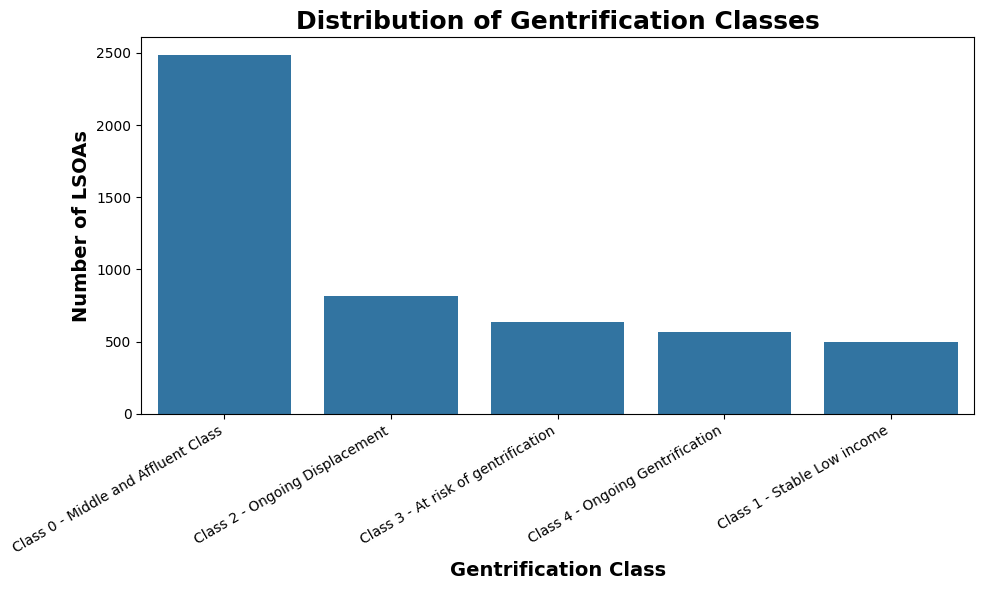

In [332]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of areas in each gentrification class
class_counts = df['gentrification_class'].value_counts(dropna=False).rename_axis('Class').reset_index(name='Count')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=class_counts, x='Class', y='Count')
plt.xticks(rotation=30, ha='right')
plt.title('Distribution of Gentrification Classes', fontsize=18, fontweight='bold')
plt.xlabel('Gentrification Class', fontsize=14, fontweight='bold')
plt.ylabel('Number of LSOAs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [333]:
import geopandas as gpd

# Load LSOA boundary
gdf = gpd.read_file(r"C:\Users\wbwha\Desktop\NLP_Gentrification_London_Prediction\Output\London_LSOA_2021.shp")

In [334]:
# Merge classification results
gdf = gdf.merge(df[['LSOA21CD', 'gentrification_class']], left_on='LSOA21CD',right_on='LSOA21CD', how='left')

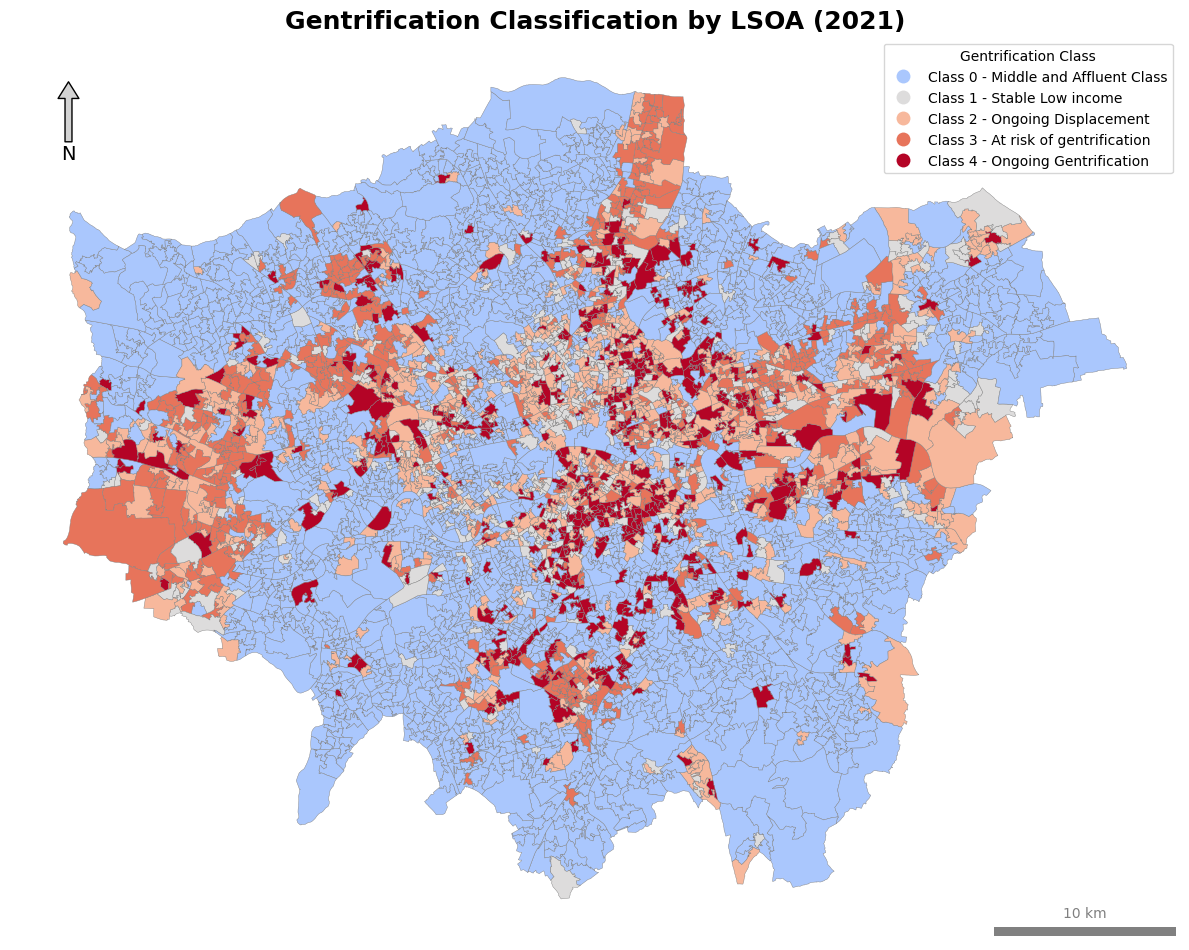

In [335]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib_scalebar.scalebar import ScaleBar

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the GeoDataFrame
gdf.plot(
    column='gentrification_class',
    cmap='coolwarm',
    vmin=-2,
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'title': 'Gentrification Class'},
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "label": "Transitional Area"
    },
    ax=ax
)

# Add scalebar (unit: meters for EPSG:27700)
scalebar = ScaleBar(
    dx=1,
    units='m',
    dimension='si-length',
    location='lower right',
    length_fraction=0.2,
    scale_loc='top',
    box_alpha=0.3,
    color='grey',   
    font_properties={'size': 10}
)
ax.add_artist(scalebar)

# Add grid lines
ax.grid(True, which='both', color='grey', linestyle='--', linewidth=0.5)

# Add north arrow
x, y, arrow_length = 0.05, 0.95, 0.08  # x/y in axis coordinates (0–1), arrow_length as fraction
ax.annotate('N',
            xy=(x, y),
            xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='lightgrey', width=5, headwidth=15),
            ha='center',
            va='center',
            fontsize=14,
            xycoords=ax.transAxes)

# Title and layout
ax.set_title("Gentrification Classification by LSOA (2021)", fontsize=18, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()
